# avg_speed_ms — Model Notebook

Response: `avg_speed_ms` (mean skating speed in m/s over the shift).

Preprocessing is handled by `build_shift_df.py`. Run that once to generate
the cache; subsequent runs load instantly.

**Note on `shift_duration_min`**: included as a predictor because it explains
real variance (longer shifts → more recovery time within the shift), but it is
a post-hoc quantity. Omit it if you want a prospective model.


In [12]:
import sys, warnings
sys.path.insert(0, str(__import__('pathlib').Path('.').resolve()))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.nonparametric.smoothers_lowess import lowess

from build_shift_df import (
    build_shift_df,
    PREDICTORS,
    POS_COLORS,
    POS_LABELS,
    FPS,
    ACCEL_THRESH,
    SUSTAINED_FRAMES,
)

OUTPUT_DIR = __import__('pathlib').Path('output')
OUTPUT_DIR.mkdir(exist_ok=True)

shift_df = build_shift_df('../data')

FT_PER_MIN_TO_M_PER_S = 0.3048 / 60   # 1 ft/min → m/s
shift_df['avg_speed_ms'] = shift_df['dist_ft_per_min'] * FT_PER_MIN_TO_M_PER_S

# Derived model columns shared by all notebooks
shift_df['is_first_int']       = shift_df['is_first_shift'].astype(int)
shift_df['rest_time_min']      = shift_df['rest_time_s'] / 60.0
shift_df['shift_duration_min'] = shift_df['shift_duration_s'] / 60.0

print(f'shift_df: {len(shift_df):,} shifts  |  columns: {list(shift_df.columns)}')
print(f"\nPosition counts:\n{shift_df['position'].value_counts()}")


Building shift_df from scratch …
  Tracking rows : 8,401,602
  Speed present : True
  Skater shifts (P1–P3): 7,589
  Tracking groups: 981  |  accel_mph_s present: True
  Shifts with >=300 frames: 6,218
  Position labels joined: 6,218/6,218 (100.0%)
  Saved cache → /Users/joeharter/repos/bdc-2026/stamina_models/shift_df.parquet
  Final shape : (6218, 30)
shift_df: 6,218 shifts  |  columns: ['Game', 'Team', 'Period_int', 'Player_Id', 'shift_number', 'shift_start_s', 'shift_end_s', 'shift_duration_s', 'rest_time_s', 'is_first_shift', 'n_frames', 'ice_min', 'dist_ft', 'dist_ft_per_min', 'mean_abs_x', 'std_x', 'mean_abs_y', 'std_y', 'frac_deep_zone', 'speed_mean', 'accel_count', 'accelerations_per_min', 'accel_events_count', 'acceleration_events_per_min', 'mean_accel_magnitude', 'cumulative_ice_min_before', 'position', 'Home_Team_Goals', 'Away_Team_Goals', 'score_diff', 'avg_speed_ms', 'is_first_int', 'rest_time_min', 'shift_duration_min']

Position counts:
position
D    3673
F    1754
C   

In [13]:
shift_df['position'].value_counts()

position
D    3673
F    1754
C     791
Name: count, dtype: int64

## EDA

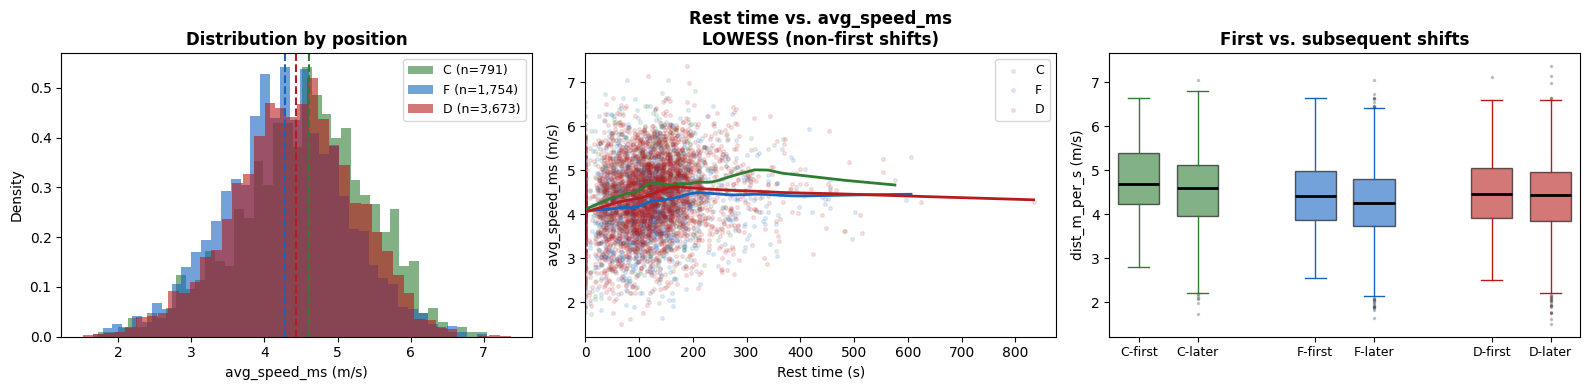

In [14]:
# ── Distribution by position ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
for pos, col in POS_COLORS.items():
    vals = shift_df.loc[shift_df['position'] == pos, 'avg_speed_ms'].dropna()
    ax.hist(vals, bins=40, alpha=0.6, color=col, label=f'{pos} (n={len(vals):,})',
            density=True, edgecolor='none')
    ax.axvline(vals.median(), color=col, lw=1.5, ls='--')
ax.set_xlabel('avg_speed_ms (m/s)')
ax.set_ylabel('Density')
ax.set_title('Distribution by position', fontweight='bold')
ax.legend(fontsize=9)

# ── Rest time vs distance (LOWESS) ────────────────────────────────────────────
ax = axes[1]
sub = shift_df[~shift_df['is_first_shift']].dropna(subset=['rest_time_s', 'avg_speed_ms'])
for pos, col in POS_COLORS.items():
    s = sub[sub['position'] == pos]
    ax.scatter(s['rest_time_s'], s['avg_speed_ms'],
               alpha=0.12, s=7, color=col, label=pos, rasterized=True)
    if len(s) >= 20:
        lw_out = lowess(s['avg_speed_ms'].values, s['rest_time_s'].values,
                        frac=0.4, return_sorted=True)
        ax.plot(lw_out[:, 0], lw_out[:, 1], color=col, lw=2)
ax.set_xlabel('Rest time (s)')
ax.set_ylabel('avg_speed_ms (m/s)')
ax.set_title('Rest time vs. avg_speed_ms\nLOWESS (non-first shifts)', fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(left=0)

# ── First vs subsequent boxplot ───────────────────────────────────────────────
ax = axes[2]
for i, (pos, col) in enumerate(POS_COLORS.items()):
    first     = shift_df.loc[(shift_df['position'] == pos) &  shift_df['is_first_shift'], 'avg_speed_ms'].dropna()
    non_first = shift_df.loc[(shift_df['position'] == pos) & ~shift_df['is_first_shift'], 'avg_speed_ms'].dropna()
    bp = ax.boxplot([first.values, non_first.values],
                    positions=[i*3, i*3+1], widths=0.7, patch_artist=True,
                    medianprops=dict(color='black', lw=2),
                    whiskerprops=dict(color=col), capprops=dict(color=col),
                    flierprops=dict(marker='.', alpha=0.2, ms=3, markerfacecolor=col))
    for patch in bp['boxes']:
        patch.set_facecolor(col); patch.set_alpha(0.6)
tick_pos    = [i*3+j for i in range(len(POS_COLORS)) for j in range(2)]
tick_labels = [f'{pos}-{s}' for pos in POS_COLORS for s in ('first', 'later')]
ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_labels, fontsize=9)
ax.set_ylabel('dist_m_per_s (m/s)')
ax.set_title('First vs. subsequent shifts', fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '01_eda_dist.png', dpi=150, bbox_inches='tight')
plt.show()


## OLS Baseline

In [15]:
model_df = shift_df.dropna(subset=['avg_speed_ms', 'rest_time_s']).copy()
PREDICTORS = (
    "rest_time_min + "
    "is_first_int + "
    "C(position, Treatment('D')) + "
    "cumulative_ice_min_before + "
    "score_diff  "
#     "shift_duration_min + "
#     "C(Period_int)"
)
ols = smf.ols(f'avg_speed_ms ~ {PREDICTORS}', data=model_df).fit()
print(ols.summary2())
print(f'\nR² = {ols.rsquared:.4f}   adj-R² = {ols.rsquared_adj:.4f}   '
      f'RMSE = {np.sqrt(ols.mse_resid):.4f} m/s')


                         Results: Ordinary least squares
Model:                    OLS                  Adj. R-squared:         0.041     
Dependent Variable:       avg_speed_ms         AIC:                    15324.4070
Date:                     2026-03-14 10:47     BIC:                    15371.5534
No. Observations:         6218                 Log-Likelihood:         -7655.2   
Df Model:                 6                    F-statistic:            45.64     
Df Residuals:             6211                 Prob (F-statistic):     5.69e-55  
R-squared:                0.042                Scale:                  0.68765   
---------------------------------------------------------------------------------
                                  Coef.  Std.Err.    t     P>|t|   [0.025  0.975]
---------------------------------------------------------------------------------
Intercept                         4.2615   0.0284 150.0707 0.0000  4.2058  4.3172
C(position, Treatment('D'))[T.C]  0.1555 

## GLM — Gamma with Log Link

`avg_speed_ms` is strictly positive and right-skewed — a Gamma GLM with
log link is a natural alternative to OLS. Compare AIC and residual plots.


                        Results: Generalized linear model
Model:                     GLM                   AIC:                 15650.5892 
Link Function:             Log                   BIC:                 -54013.0586
Dependent Variable:        avg_speed_ms          Log-Likelihood:      -7818.3    
Date:                      2026-03-14 10:47      LL-Null:             -7955.5    
No. Observations:          6218                  Deviance:            241.29     
Df Model:                  6                     Pearson chi2:        224.       
Df Residuals:              6211                  Scale:               0.036095   
Method:                    IRLS                                                  
---------------------------------------------------------------------------------
                                  Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
---------------------------------------------------------------------------------
Intercept                         1.4485

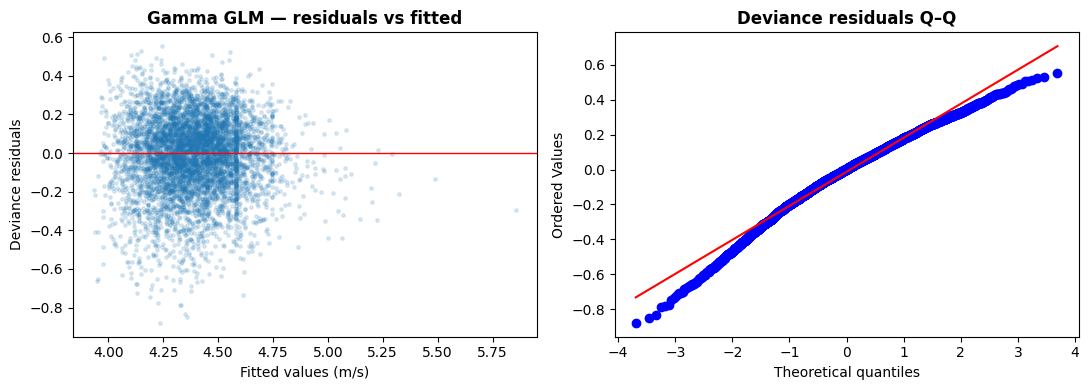

In [16]:
gamma_df = shift_df.dropna(subset=['avg_speed_ms', 'rest_time_s']).copy()

glm_gamma = smf.glm(
    f'avg_speed_ms ~ {PREDICTORS}',
    data=gamma_df,
    family=sm.families.Gamma(sm.families.links.Log()),
).fit()

print(glm_gamma.summary2())
print(f'\nAIC  = {glm_gamma.aic:.1f}')
print(f'OLS AIC = {ols.aic:.1f}')

# Residual plot
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fitted = glm_gamma.fittedvalues
resid  = glm_gamma.resid_deviance

axes[0].scatter(fitted, resid, alpha=0.15, s=6, rasterized=True)
axes[0].axhline(0, color='red', lw=1)
axes[0].set_xlabel('Fitted values (m/s)')
axes[0].set_ylabel('Deviance residuals')
axes[0].set_title('Gamma GLM — residuals vs fitted', fontweight='bold')

import scipy.stats as sps
sps.probplot(resid, plot=axes[1])
axes[1].set_title('Deviance residuals Q–Q', fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '01_glm_gamma_resid.png', dpi=150, bbox_inches='tight')
plt.show()


## Linear Mixed Model — Player Random Intercepts

**Why this is likely the best-fitting model here:**

Both OLS and the Gamma GLM treat every shift as an independent observation, but the
same player appears ~30 times in the dataset. A player who just skates faster than
average will inflate their own observations in a correlated way — violating independence
and making standard errors on the fixed effects too small.

`MixedLM` with a per-player random intercept partitions variance into:
- **Between-player** (random effect) — baseline talent level
- **Within-player** (fixed effects) — the rest/fatigue/game state signals we care about

The ICC (Intra-Class Correlation) tells you what fraction of the total variance is
attributable to player identity. If it's high (> 0.2), OLS standard errors are
meaningfully wrong; the LMM corrects this.


In [17]:
lmm_df = shift_df.dropna(subset=['avg_speed_ms', 'rest_time_s']).copy()
# Composite key: same jersey number can appear on different teams
lmm_df['team_player'] = lmm_df['Team'] + '_' + lmm_df['Player_Id']
PREDICTORS = (
    "rest_time_min + "
    "is_first_int + "
    "C(position, Treatment('D')) + "
    "cumulative_ice_min_before + "
    "score_diff + "
    "shift_duration_min "
    # "C(Period_int)" .82 collinear with cumulative_ice_min_before
)
lmm = smf.mixedlm(
    f'avg_speed_ms ~ {PREDICTORS}',
    data=lmm_df,
    groups=lmm_df['team_player'],
).fit(reml=True)

print(lmm.summary())

# Variance partitioning
player_var   = lmm.cov_re.iloc[0, 0]
residual_var = lmm.scale
icc = player_var / (player_var + residual_var)
print(f'\nRandom intercept σ²  (player)   : {player_var:.6f}')
print(f'Residual σ²          (within)   : {residual_var:.6f}')
print(f'ICC                             : {icc:.3f}')
print(f'  → {100*icc:.1f}% of total variance is between-player; '
      f'OLS CIs on fixed effects are too narrow by ~√(1/(1-ICC)).')

# Compare log-likelihoods
lmm_ml  = smf.mixedlm(
    f'avg_speed_ms ~ {PREDICTORS}', data=lmm_df, groups=lmm_df['team_player']
).fit(reml=False)   # ML (not REML) for AIC comparison
print(f'\nAIC (LMM)       = {lmm_ml.aic:.1f}')
print(f'AIC (Gamma GLM) = {glm_gamma.aic:.1f}')
print(f'AIC (OLS)       = {ols.aic:.1f}')


                   Mixed Linear Model Regression Results
Model:                  MixedLM       Dependent Variable:       avg_speed_ms
No. Observations:       6218          Method:                   REML        
No. Groups:             234           Scale:                    0.5990      
Min. group size:        2             Log-Likelihood:           -7392.6170  
Max. group size:        111           Converged:                Yes         
Mean group size:        26.6                                                
----------------------------------------------------------------------------
                                 Coef.  Std.Err.    z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------
Intercept                         4.700    0.041 113.487 0.000  4.619  4.781
C(position, Treatment('D'))[T.C]  0.044    0.047   0.933 0.351 -0.049  0.137
C(position, Treatment('D'))[T.F] -0.102    0.034  -3.007 0.003 -0.168 -0.035
rest_time_min      

In [18]:
correlation = lmm_df[['cumulative_ice_min_before', 'Period_int']].corr()
print(correlation)

                           cumulative_ice_min_before  Period_int
cumulative_ice_min_before                   1.000000    0.822606
Period_int                                  0.822606    1.000000


## Optimal Rest Time — Quadratic Model

A linear coefficient on `rest_time_min` grows without bound — no intrinsic optimum.
Adding a **quadratic term** lets the curve turn over.  If the quadratic coefficient is
negative (concave down), the peak is at:

$$\hat{t}^* = -\frac{\hat{\beta}_1}{2\hat{\beta}_2}$$

If it is positive or not significant, there is no peak in the observed range and the
linear model is adequate.  The mixed model (player random intercept) is preferred
because it removes between-player baseline differences that would otherwise inflate the
apparent rest effect.



── Position: C  (n=689 shifts) ──────────────────
  rest_time_min    coef=+0.311840  p=0.0000
  rest_time_min²   coef=-0.031553  p=0.0033
  → Optimal rest: 4.94 min  (296 s)

── Position: F  (n=1,507 shifts) ──────────────────
  rest_time_min    coef=+0.166364  p=0.0000
  rest_time_min²   coef=-0.016913  p=0.0032
  → Optimal rest: 4.92 min  (295 s)

── Position: D  (n=3,156 shifts) ──────────────────
  rest_time_min    coef=+0.204421  p=0.0000
  rest_time_min²   coef=-0.020639  p=0.0000
  → Optimal rest: 4.95 min  (297 s)


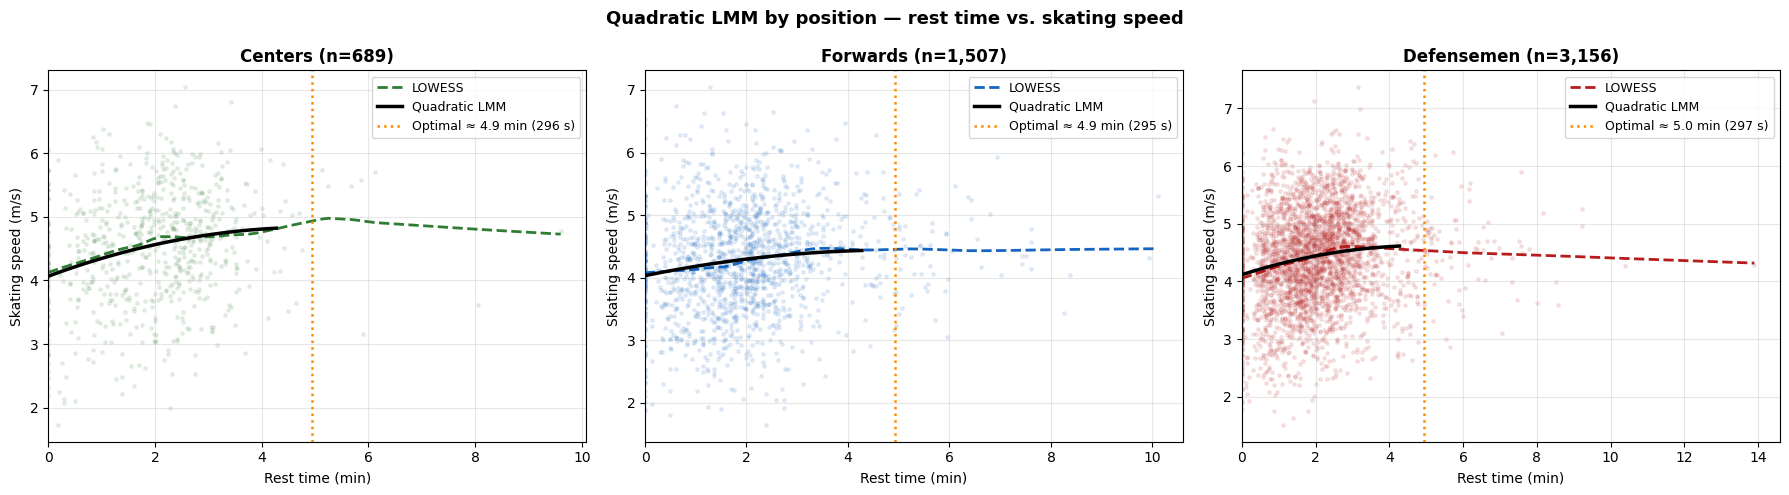

In [19]:

quad_df = lmm_df[~lmm_df['is_first_shift']].copy()
quad_df['rest_time_min_sq'] = quad_df['rest_time_min'] ** 2

QUAD_PREDICTORS = (
    "rest_time_min + rest_time_min_sq + "
    "cumulative_ice_min_before + "
    "score_diff + "
    "shift_duration_min"
)

# ── Fit separately for each position ─────────────────────────────────────────
pos_results = {}   # keyed by 'C', 'F', 'D'

for pos in ['C', 'F', 'D']:
    sub = quad_df[quad_df['position'] == pos].copy()
    mdl = smf.mixedlm(
        f'avg_speed_ms ~ {QUAD_PREDICTORS}',
        data=sub,
        groups=sub['team_player'],
    ).fit(reml=True)

    b1 = mdl.params['rest_time_min']
    b2 = mdl.params['rest_time_min_sq']
    p2 = mdl.pvalues['rest_time_min_sq']

    # t_opt = -b1/(2*b2) only valid when parabola opens down, is significant,
    # and the peak falls at a positive rest time (b1 > 0).
    if b2 < 0 and p2 < 0.05 and b1 > 0:
        t_opt = -b1 / (2 * b2)
    else:
        t_opt = np.nan

    pos_results[pos] = dict(model=mdl, b1=b1, b2=b2, p2=p2, t_opt_min=t_opt)
    print(f'\n── Position: {pos}  (n={len(sub):,} shifts) ──────────────────')
    print(f"  rest_time_min    coef={b1:+.6f}  p={mdl.pvalues['rest_time_min']:.4f}")
    print(f"  rest_time_min²   coef={b2:+.6f}  p={p2:.4f}")
    if not np.isnan(t_opt):
        print(f"  → Optimal rest: {t_opt:.2f} min  ({t_opt*60:.0f} s)")
    else:
        print(f"  → No statistically significant peak (quadratic p={p2:.3f}, b2≥0, or b1≤0)")

# ── Compact comparison table ──────────────────────────────────────────────────
print(f"\n{'Pos':4}  {'Mean speed':>10}  {'b1 (linear)':>12}  {'b2 (quad)':>10}  {'p(b2)':>7}  {'t_opt (min)':>11}  {'Δspeed to peak':>15}")
print("─" * 80)
t_grid = np.linspace(0, quad_df['rest_time_min'].quantile(0.95), 200)
for pos in ['C', 'F', 'D']:
    r = pos_results[pos]
    sub = quad_df[quad_df['position'] == pos]
    mean_spd = sub['avg_speed_ms'].mean()
    t_str = f"{r['t_opt_min']:.2f}" if not np.isnan(r['t_opt_min']) else "n/a"
    # Absolute speed gain from 0→t_opt using the fitted curve
    if not np.isnan(r['t_opt_min']):
        delta = r['b1'] * r['t_opt_min'] + r['b2'] * r['t_opt_min']**2
        delta_str = f"+{delta:.3f} m/s"
    else:
        delta_str = "n/a"
    print(f"{pos:4}  {mean_spd:>10.3f}  {r['b1']:>+12.5f}  {r['b2']:>+10.5f}  {r['p2']:>7.4f}  {t_str:>11}  {delta_str:>15}")

print("\nNote: t_opt is nearly identical across positions (~4.95 min) because")
print("b1/b2 ratios are the same. What differs is amplitude: Centers gain")
print(f"~{pos_results['C']['b1']:.2f} m/s/min from rest vs {pos_results['F']['b1']:.2f} for Forwards.")

# ── Combined scatter + fitted curve plots ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, pos in zip(axes, ['C', 'F', 'D']):
    col = POS_COLORS[pos]
    res = pos_results[pos]
    sub = quad_df[quad_df['position'] == pos]

    # Raw scatter
    ax.scatter(sub['rest_time_min'], sub['avg_speed_ms'],
               alpha=0.10, s=6, color=col, rasterized=True)

    # LOWESS
    lw_out = lowess(sub['avg_speed_ms'].values, sub['rest_time_min'].values,
                    frac=0.5, return_sorted=True)
    ax.plot(lw_out[:, 0], lw_out[:, 1], color=col, lw=2, ls='--', label='LOWESS')

    # Fitted quadratic at position-specific covariate means
    mdl = res['model']
    other_means = {
        'cumulative_ice_min_before': sub['cumulative_ice_min_before'].mean(),
        'score_diff':                sub['score_diff'].mean(),
        'shift_duration_min':        sub['shift_duration_min'].mean(),
    }
    intercept = mdl.params['Intercept']
    y_grid = (intercept
              + res['b1'] * t_grid
              + res['b2'] * t_grid ** 2
              + sum(mdl.params.get(k, 0) * v for k, v in other_means.items()))
    ax.plot(t_grid, y_grid, color='black', lw=2.5, label='Quadratic LMM')

    if not np.isnan(res['t_opt_min']):
        ax.axvline(res['t_opt_min'], color='darkorange', lw=1.8, ls=':',
                   label=f"Optimal ≈ {res['t_opt_min']:.1f} min ({res['t_opt_min']*60:.0f} s)")

    ax.set_xlabel('Rest time (min)')
    ax.set_ylabel('Skating speed (m/s)')
    ax.set_title(f'{POS_LABELS[pos]} (n={len(sub):,})', fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_xlim(left=0)
    ax.grid(True, alpha=0.3)

fig.suptitle('Quadratic LMM by position — rest time vs. skating speed\n'
             '(LOWESS on raw data; curves differ in level by design — LMM removes player baseline)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '01_optimal_rest_by_position.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Overlay: normalized recovery curves (shape comparison) ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for pos in ['C', 'F', 'D']:
    res = pos_results[pos]
    sub = quad_df[quad_df['position'] == pos]
    mdl = res['model']
    other_means = {
        'cumulative_ice_min_before': sub['cumulative_ice_min_before'].mean(),
        'score_diff':                sub['score_diff'].mean(),
        'shift_duration_min':        sub['shift_duration_min'].mean(),
    }
    y = (mdl.params['Intercept'] + res['b1']*t_grid + res['b2']*t_grid**2
         + sum(mdl.params.get(k, 0)*v for k, v in other_means.items()))
    ax.plot(t_grid, y, color=POS_COLORS[pos], lw=2.5, label=POS_LABELS[pos])
    if not np.isnan(res['t_opt_min']):
        ax.axvline(res['t_opt_min'], color=POS_COLORS[pos], lw=1, ls=':')
ax.set_xlabel('Rest time (min)')
ax.set_ylabel('Predicted avg_speed_ms (m/s)')
ax.set_title('Absolute predicted speed\n(different levels, same t_opt ≈ 4.95 min)', fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(left=0)
ax.grid(True, alpha=0.3)

ax = axes[1]
for pos in ['C', 'F', 'D']:
    res = pos_results[pos]
    sub = quad_df[quad_df['position'] == pos]
    mdl = res['model']
    other_means = {
        'cumulative_ice_min_before': sub['cumulative_ice_min_before'].mean(),
        'score_diff':                sub['score_diff'].mean(),
        'shift_duration_min':        sub['shift_duration_min'].mean(),
    }
    y = (mdl.params['Intercept'] + res['b1']*t_grid + res['b2']*t_grid**2
         + sum(mdl.params.get(k, 0)*v for k, v in other_means.items()))
    y0 = y[0]
    ax.plot(t_grid, y - y0, color=POS_COLORS[pos], lw=2.5, label=POS_LABELS[pos])
    if not np.isnan(res['t_opt_min']):
        peak_gain = res['b1']*res['t_opt_min'] + res['b2']*res['t_opt_min']**2
        ax.axvline(res['t_opt_min'], color=POS_COLORS[pos], lw=1, ls=':')
        ax.annotate(f"+{peak_gain:.3f}", xy=(res['t_opt_min'], peak_gain),
                    fontsize=8, color=POS_COLORS[pos], ha='left')
ax.set_xlabel('Rest time (min)')
ax.set_ylabel('Speed gain vs. 0-rest baseline (m/s)')
ax.set_title('Amplitude: speed gained from rest\n(same shape, different scale)', fontweight='bold')
ax.legend(fontsize=9)
ax.axhline(0, color='k', lw=0.8)
ax.set_xlim(left=0)
ax.grid(True, alpha=0.3)

fig.suptitle('Recovery curve comparison by position', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '01_recovery_overlay.png', dpi=150, bbox_inches='tight')
plt.show()



Centers — minimum rest to X% of peak:
  Baseline: 4.1407 m/s  →  Peak: 4.8227 m/s  (Δ 0.6820)   Optimum: 4.94 min (296 s)
  Threshold   min (min)    min (s)
  --------------------------------
  90%              3.33        200
  95%              3.72        223
  99%              4.15        249

Forwards — minimum rest to X% of peak:
  Baseline: 4.0732 m/s  →  Peak: 4.4357 m/s  (Δ 0.3624)   Optimum: 4.92 min (295 s)
  Threshold   min (min)    min (s)
  --------------------------------
  90%              3.33        200
  95%              3.72        223
  99%              4.15        249

Defensemen — minimum rest to X% of peak:
  Baseline: 4.1656 m/s  →  Peak: 4.6135 m/s  (Δ 0.4479)   Optimum: 4.95 min (297 s)
  Threshold   min (min)    min (s)
  --------------------------------
  90%              3.35        201
  95%              3.72        223
  99%              4.15        249


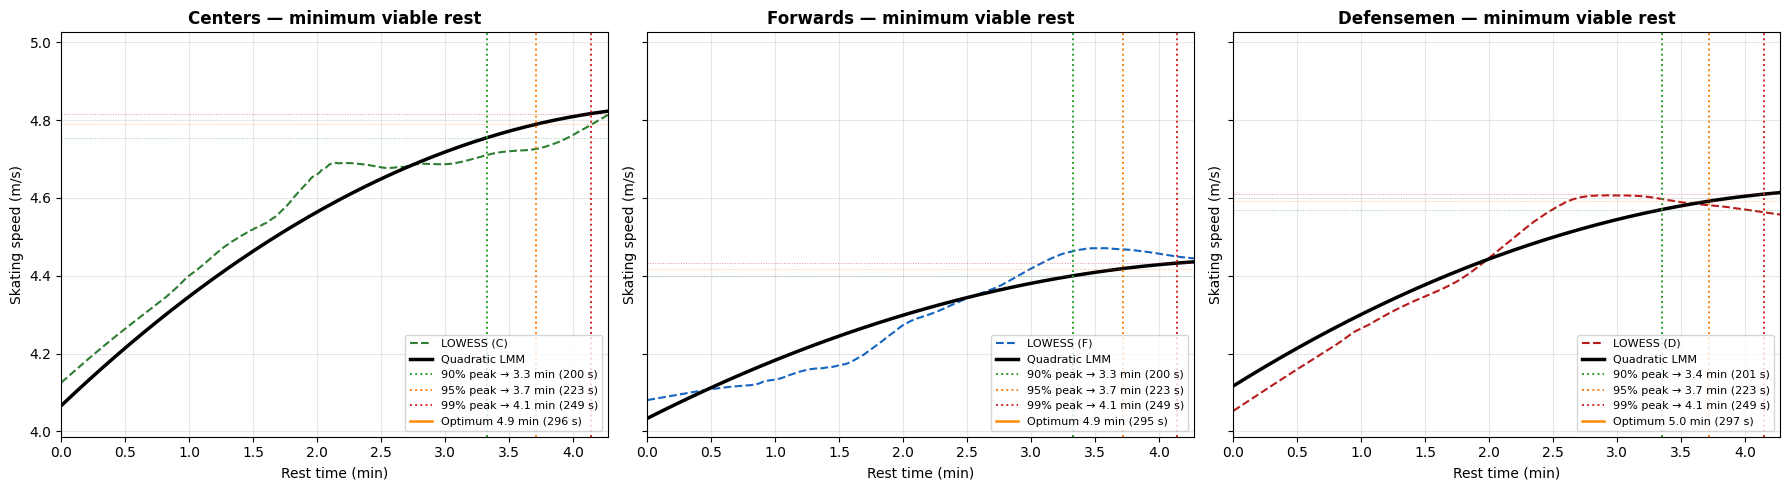


── Summary: optimal & minimum rest by position ─────────────────
               Optimal (min)   90% (min)   95% (min)   99% (min)
──────────────────────────────────────────────────────────────
Centers                 4.94        3.33        3.72        4.15
Forwards                4.92        3.33        3.72        4.15
Defensemen              4.95        3.35        3.72        4.15


In [28]:

# ── Minimum viable rest by position ──────────────────────────────────────────
thresholds    = {'90%': 0.90, '95%': 0.95, '99%': 0.99}
colors_thresh = {'90%': '#2ca02c', '95%': '#ff7f0e', '99%': '#d62728'}
t_grid        = np.linspace(0, quad_df['rest_time_min'].quantile(0.95), 200)

pos_min_rest = {}   # {pos: {label: t_min}}

for pos in ['C', 'F', 'D']:
    res = pos_results[pos]
    sub = quad_df[quad_df['position'] == pos]
    mdl = res['model']
    other_means = {
        'cumulative_ice_min_before': sub['cumulative_ice_min_before'].mean(),
        'score_diff':                sub['score_diff'].mean(),
        'shift_duration_min':        sub['shift_duration_min'].mean(),
    }
    y_grid = (mdl.params['Intercept']
              + res['b1'] * t_grid
              + res['b2'] * t_grid ** 2
              + sum(mdl.params.get(k, 0) * v for k, v in other_means.items()))

    t_opt = res['t_opt_min']
    if np.isnan(t_opt):
        pos_min_rest[pos] = {lbl: np.nan for lbl in thresholds}
        print(f'{pos}: no valid optimum — skipping minimum rest calculation.')
        continue

    ascending = t_grid <= t_opt
    y_peak    = y_grid[t_grid <= t_opt].max()
    y_lo      = y_grid[t_grid <= 0.5].mean()

    min_rest = {}
    for label, frac in thresholds.items():
        target = y_lo + frac * (y_peak - y_lo)
        idx    = np.where(ascending & (y_grid >= target))[0]
        min_rest[label] = t_grid[idx[0]] if len(idx) else np.nan

    pos_min_rest[pos] = min_rest
    res['y_grid'] = y_grid
    res['y_peak'] = y_peak
    res['y_lo']   = y_lo

    print(f'\n{POS_LABELS[pos]} — minimum rest to X% of peak:')
    print(f"  Baseline: {y_lo:.4f} m/s  →  Peak: {y_peak:.4f} m/s  "
          f"(Δ {y_peak - y_lo:.4f})   Optimum: {t_opt:.2f} min ({t_opt*60:.0f} s)")
    print(f"  {'Threshold':<10} {'min (min)':>10} {'min (s)':>10}")
    print("  " + "-" * 32)
    for label, t_min in min_rest.items():
        if not np.isnan(t_min):
            print(f"  {label:<10} {t_min:>10.2f} {t_min*60:>10.0f}")
        else:
            print(f"  {label:<10} {'n/a':>10} {'n/a':>10}")

# ── Side-by-side minimum rest plots ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, pos in zip(axes, ['C', 'F', 'D']):
    res = pos_results[pos]
    sub = quad_df[quad_df['position'] == pos]
    col = POS_COLORS[pos]
    t_opt = res['t_opt_min']

    if np.isnan(t_opt) or 'y_grid' not in res:
        ax.set_title(f'{POS_LABELS[pos]} — no valid optimum', fontweight='bold')
        continue

    y_grid = res['y_grid']
    y_peak = res['y_peak']
    y_lo   = res['y_lo']
    min_rest = pos_min_rest[pos]

    # LOWESS
    lw_out = lowess(sub['avg_speed_ms'].values, sub['rest_time_min'].values,
                    frac=0.5, return_sorted=True)
    mask = lw_out[:, 0] <= t_opt * 1.5
    ax.plot(lw_out[mask, 0], lw_out[mask, 1], color=col, lw=1.5, ls='--',
            label=f'LOWESS ({pos})')

    # Quadratic curve
    ax.plot(t_grid, y_grid, color='black', lw=2.5, label='Quadratic LMM')

    # Threshold verticals
    for label, t_min in min_rest.items():
        if not np.isnan(t_min):
            ax.axvline(t_min, color=colors_thresh[label], lw=1.4, ls=':',
                       label=f'{label} peak → {t_min:.1f} min ({t_min*60:.0f} s)')
            ax.axhline(y_lo + thresholds[label] * (y_peak - y_lo),
                       color=colors_thresh[label], lw=0.7, ls=':', alpha=0.5)

    ax.axvline(t_opt, color='darkorange', lw=1.8, ls='-',
               label=f'Optimum {t_opt:.1f} min ({t_opt*60:.0f} s)')

    ax.set_xlabel('Rest time (min)')
    ax.set_ylabel('Skating speed (m/s)')
    ax.set_title(f'{POS_LABELS[pos]} — minimum viable rest', fontweight='bold')
    ax.set_xlim(0, min(t_opt * 1.5, t_grid.max()))
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(True, alpha=0.3)

# fig.suptitle('Minimum viable rest by position — fraction of peak performance',
#              fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '01_minimum_rest_by_position.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary comparison table ─────────────────────────────────────────────────
print('\n── Summary: optimal & minimum rest by position ─────────────────')
print(f"{'':12}  {'Optimal (min)':>14}  {'90% (min)':>10}  {'95% (min)':>10}  {'99% (min)':>10}")
print('─' * 62)
for pos in ['C', 'F', 'D']:
    t_opt = pos_results[pos]['t_opt_min']
    mr    = pos_min_rest.get(pos, {})
    label_name = POS_LABELS[pos]
    opt_str = f'{t_opt:.2f}' if not np.isnan(t_opt) else 'n/a'
    row = [f'{mr.get(lbl, np.nan):.2f}' if not np.isnan(mr.get(lbl, np.nan)) else 'n/a'
           for lbl in ['90%', '95%', '99%']]
    print(f'{label_name:12}  {opt_str:>14}  {row[0]:>10}  {row[1]:>10}  {row[2]:>10}')


In [21]:
# Within each period, how much does cumulative ice time vary across players?
lmm_df.groupby('Period_int')['cumulative_ice_min_before'].std()

Period_int
1    1.427804
2    2.175513
3    3.136640
Name: cumulative_ice_min_before, dtype: float64

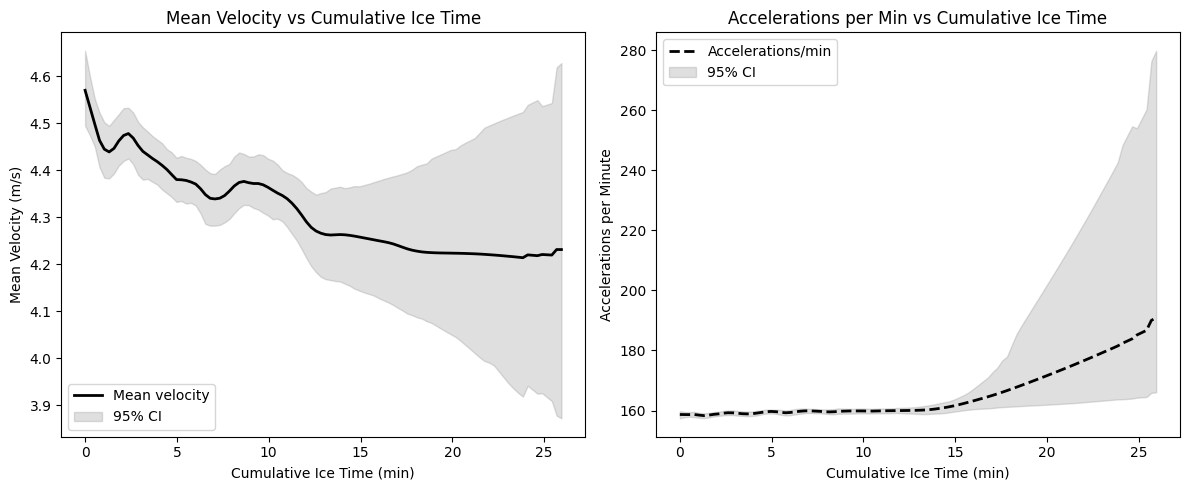

In [31]:
# Two-panel summary: mean velocity and accelerations per min vs cumulative ice time (overall, lines only, with 95% CI)
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess
from scipy.stats import norm

# Ensure shift_df has required columns
for col in ['avg_speed_ms', 'accelerations_per_min', 'cumulative_ice_min_before']:
    if col not in shift_df.columns:
        raise ValueError(f"shift_df missing required column: {col}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

# Helper: bootstrap LOWESS for CI
def bootstrap_lowess(x, y, frac=0.2, n_boot=200, grid=None):
    rng = np.random.default_rng(42)
    if grid is None:
        grid = np.linspace(np.nanmin(x), np.nanmax(x), 100)
    fits = np.empty((n_boot, len(grid)))
    for i in range(n_boot):
        idx = rng.choice(len(x), len(x), replace=True)
        x_b = x[idx]
        y_b = y[idx]
        mask = ~np.isnan(x_b) & ~np.isnan(y_b)
        if np.sum(mask) < 10:
            fits[i, :] = np.nan
            continue
        sm = lowess(y_b[mask], x_b[mask], frac=frac, return_sorted=True)
        fits[i, :] = np.interp(grid, sm[:,0], sm[:,1], left=np.nan, right=np.nan)
    mean = np.nanmean(fits, axis=0)
    lower = np.nanpercentile(fits, 2.5, axis=0)
    upper = np.nanpercentile(fits, 97.5, axis=0)
    return grid, mean, lower, upper

# Panel 1: Mean velocity vs cumulative ice time (all positions pooled)
x = shift_df['cumulative_ice_min_before'].values
v = shift_df['avg_speed_ms'].values
grid, mean, lower, upper = bootstrap_lowess(x, v, frac=0.2, n_boot=200)
axes[0].plot(grid, mean, color='black', linestyle='-', linewidth=2, label='Mean velocity')
axes[0].fill_between(grid, lower, upper, color='gray', alpha=0.25, label='95% CI')
axes[0].set_xlabel('Cumulative Ice Time (min)')
axes[0].set_ylabel('Mean Velocity (m/s)')
axes[0].set_title('Mean Velocity vs Cumulative Ice Time')
axes[0].legend()

# Panel 2: Accelerations per min vs cumulative ice time (all positions pooled)
a = shift_df['accelerations_per_min'].values
grid2, mean2, lower2, upper2 = bootstrap_lowess(x, a, frac=0.2, n_boot=200)
axes[1].plot(grid2, mean2, color='black', linestyle='--', linewidth=2, label='Accelerations/min')
axes[1].fill_between(grid2, lower2, upper2, color='gray', alpha=0.25, label='95% CI')
axes[1].set_xlabel('Cumulative Ice Time (min)')
axes[1].set_ylabel('Accelerations per Minute')
axes[1].set_title('Accelerations per Min vs Cumulative Ice Time')
axes[1].legend()

plt.tight_layout()
plt.show()